# RAG Pipeline 통합 테스트 시나리오

### 1. 문서 메타 정보

| 항목            | 내용                                                                 |
| --------------- | ---------------------------------------------------------------------|
| **작성자**      | 고아라                                                               |
| **작성일**      | 2026-04-08                                                           |
| **테스트 목적** | RAG 파이프라인 전체 통합 테스트 및 품질·성능 지표 측정 |
| **환경 구분**   | 로컬 개발 환경 (Windows / .venv)                                     |
| **검증 범위**   | 검색 품질 / 할루시네이션 방지 / 엣지 케이스 / Latency / 톤앤매너     |
| **실행 단계**   | Phase 1: 단위 테스트 (Qdrant 불필요) / Phase 2: 통합 테스트 (Qdrant required) |

### 2. 테스트 대상 및 검증 범위

##### 노드별 검증 범위

| 노드              | 구현 위치                        | 검증 항목                               | 실행 단계 |
| ----------------- | -------------------------------- | --------------------------------------- | --------- |
| `moderator_1`     | SENSITIVE_PATTERNS + 정규식      | 민감정보 감지, 오탐 방지                | PHASE 1   |
| `moderator_2`     | MODERATOR_2_SYSTEM_PROMPT + LLM  | 확답/법률자문 차단, 메타데이터 추출     | PHASE 1   |
| `retrieve`        | QdrantStore.search()             | 유사 문서 검색, 메타데이터 필터 적용    | PHASE 2   |
| `check_relevance` | RELEVANCE_THRESHOLD (기본 0.35)  | 유사도 임계치 판단, fallback 처리       | PHASE 2   |
| `generator`       | GENERATOR_SYSTEM_PROMPT + LLM    | 문서 기반 답변 생성, Tavily 조건부 실행 | PHASE 2   |
| `formatter`       | FORMATTER_SYSTEM_PROMPT + LLM    | 답변 양식 정제                          | PHASE 2   |
| `moderator_3`     | DEFINITIVE_PATTERNS + LLM        | 확답 표현 필터 (정규식 1차 → LLM 2차)   | PHASE 2   |

##### 평가 지표

| 지표              | 정의                                            | 계산 방식                    | 실행 단계  |
| ----------------- | ----------------------------------------------- | ---------------------------- | ---------- |
| **PASS/FAIL**     | 노드별 차단/통과 기준 충족 여부                 | 예상값 vs 실제값 비교        | PHASE 1    |
| **Recall@k**      | 정답 키워드가 상위 k개 검색 결과에 포함된 비율  | hit / total                  | PHASE 2    |
| **MRR**           | 정답이 처음 등장한 순위의 평균 역수             | mean(1 / rank_of_first_hit)  | PHASE 2    |
| **Hit Rate**      | 1개 이상 정답 포함 질의 비율                    | hit_count / total_queries    | PHASE 2    |
| **Faithfulness**  | 답변 근거가 검색 문서 내에 있는가               | 키워드 기반 포함 여부        | PHASE 2    |
| **Latency (p95)** | 전체 파이프라인 소요 시간 95번째 백분위수       | 초 단위                      | PHASE 2    |
| **Tone_OK**       | 확답 표현 없는지 여부                           | DEFINITIVE_PATTERNS 기준     | PHASE 2    |

### 3. 테스트 케이스 구성

PHASE 1 — 단위 테스트 (Qdrant 불필요)
  - moderator_1 단위 테스트 (정규식 기반)
  - moderator_2 단위 테스트 (LLM 기반)
  - moderator_3 단위 테스트 (정규식 + LLM)

PHASE 2 — 통합 테스트 (Qdrant 필요)
  - 정상 통과 (전체 파이프라인, 다양한 질문 패턴)
  - 할루시네이션 방지 검증
  - 유사도 차단 (check_relevance)

---
### 4. 환경 설정

In [2]:
# !pip install matplotlib

In [3]:
import sys
sys.path.insert(0, '..')

import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pathlib import Path 

load_dotenv(dotenv_path='../.env')

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

print("환경 설정 완료")

환경 설정 완료


### 5. Phase 1 - 단위 테스트 (Qdrant 없이 실행 가능)

##### 5-1. Moderator_1 단위 테스트 (정규식, Regex)

In [4]:
import re
# 정규실으로 개인정보 패턴을 사전에 정의해두고, 입력값에 패턴이 매칭되면 차단하는 로직을 테스트한다.

SENSITIVE_PATTERNS = [
    (r'(?<!\d)\d{6}[\s-]?[1-4]\d{6}(?!\d)', "주민등록번호"),
    (r'(?<!\d)\d{6}[\s-]?[5-8]\d{6}(?!\d)', "외국인등록번호"),
    (r'(?<!\d)\d{3}[\s-]?\d{2}[\s-]?\d{5}(?!\d)', "사업자등록번호"),
    (r'(?<!\d)\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b(?!\d)', "카드번호"),
    (r'(?<!\d)\d{3,6}[-\s]?\d{2,6}[-\s]?\d{5,8}(?!\d)', "계좌번호"),
    (r'(?<!\d)(010|011|016|017|018|019)[-\s]?\d{3,4}[-\s]?\d{4}(?!\d)', "전화번호"),
]
# \d{6} → 숫자 6개 (생년월일)
# [\s-]? → 하이픈(-)이나 공백이 있어도 되고 없어도 됨
# [1-4]\d{6} → 1~4로 시작하는 숫자 7개 (성별+일련번호)
# (?<!\d) / (?!\d) → 앞뒤에 다른 숫자가 붙어있으면 무시 (오탐 방지)
def detect_sensitive(text: str) -> tuple[bool, list[str]]:
    ''' 
    민감정보 감지합수
    '''
    detected = []
    for pattern, label in SENSITIVE_PATTERNS:
        if re.search(pattern, text):
            detected.append(label)
    return len(detected) > 0, detected


# ====테스트 케이스===========================
MODERATOR_1_CASES = [
    # (test_id, 설명, 입력, 감지 예상, 예상 항목)
    ("A01", "주민번호 하이픈 있음 → 차단", "주민번호 830909-2143567입니다", True, ["주민등록번호"]),
    ("A02", "주민번호 하이픈 없음 → 차단", "주민번호 9903091234567입니다", True, ["주민등록번호"]),
    ("A03", "외국인등록번호 → 차단", "외국인번호 801230-5234567입니다", True, ["외국인등록번호"]),
    ("A04", "사업자등록번호 → 차단", "사업자번호 123-45-67890입니다", True, ["사업자등록번호"]),
    ("A05", "카드번호 → 차단", "카드번호 1234-5678-9012-3456", True, ["카드번호"]),
    ("A06", "계좌번호 → 차단", "110-195-456789로 보내주세요", True, ["계좌번호"]),
    ("A07", "전화번호 → 차단", "010-1234-5678로 연락주세요", True, ["전화번호"]),
    ("A08", "'주민번호' 단어만 (번호 없음) → 통과", "주민번호 없이 대항력 취득 가능?", False, []),
    ("A09", "정상 임대차 질문 → 통과", "보증금 반환 기한이 어떻게 되나요?", False, []),
    ("A10", "법령 키워드만 → 통과", "주택임대차보호법 제3조 내용 알려주세요", False, []),
]


# ====실행 ===================================
print("=== PHASE 1 - moderator_1 단위 테스트 ===\n")
a_results = []
all_pass = True

for test_id, desc, text, expect_detected, expect_items in MODERATOR_1_CASES:
    detected, items = detect_sensitive(text)
    pass_yn = (detected == expect_detected)
    if not pass_yn:
        all_pass = False

    status = "PASS" if pass_yn else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f" 입력: {text[:50]}")
    print(f" 감지: {detected} (예상: {expect_detected}) | 항목: {items}")
    print()

    a_results.append({
        'test_id': test_id,
        'group': 'A_moderator1',
        'description': desc,
        'detected': detected,
        'expected': expect_detected,
        'items': items,
        'status': "PASS" if pass_yn else "FAIL",
    })

print(f"결과: {'전체 통과' if all_pass else '일부 실패 → 정규식 조정 필요'}")
a_df = pd.DataFrame(a_results)
a_df

=== PHASE 1 - moderator_1 단위 테스트 ===

[A01] PASS | 주민번호 하이픈 있음 → 차단
 입력: 주민번호 830909-2143567입니다
 감지: True (예상: True) | 항목: ['주민등록번호', '계좌번호']

[A02] PASS | 주민번호 하이픈 없음 → 차단
 입력: 주민번호 9903091234567입니다
 감지: True (예상: True) | 항목: ['주민등록번호', '계좌번호']

[A03] PASS | 외국인등록번호 → 차단
 입력: 외국인번호 801230-5234567입니다
 감지: True (예상: True) | 항목: ['외국인등록번호', '계좌번호']

[A04] PASS | 사업자등록번호 → 차단
 입력: 사업자번호 123-45-67890입니다
 감지: True (예상: True) | 항목: ['사업자등록번호', '계좌번호']

[A05] PASS | 카드번호 → 차단
 입력: 카드번호 1234-5678-9012-3456
 감지: True (예상: True) | 항목: ['카드번호']

[A06] PASS | 계좌번호 → 차단
 입력: 110-195-456789로 보내주세요
 감지: True (예상: True) | 항목: ['계좌번호']

[A07] PASS | 전화번호 → 차단
 입력: 010-1234-5678로 연락주세요
 감지: True (예상: True) | 항목: ['전화번호']

[A08] PASS | '주민번호' 단어만 (번호 없음) → 통과
 입력: 주민번호 없이 대항력 취득 가능?
 감지: False (예상: False) | 항목: []

[A09] PASS | 정상 임대차 질문 → 통과
 입력: 보증금 반환 기한이 어떻게 되나요?
 감지: False (예상: False) | 항목: []

[A10] PASS | 법령 키워드만 → 통과
 입력: 주택임대차보호법 제3조 내용 알려주세요
 감지: False (예상: False) | 항목: []

결과: 전체 통과


,test_id,group,description,detected,expected,items,status
0,A01,A_moderator1,주민번호 하이픈 있음 → 차단,True,True,"[주민등록번호, 계좌번호]",PASS
1,A02,A_moderator1,주민번호 하이픈 없음 → 차단,True,True,"[주민등록번호, 계좌번호]",PASS
2,A03,A_moderator1,외국인등록번호 → 차단,True,True,"[외국인등록번호, 계좌번호]",PASS
3,A04,A_moderator1,사업자등록번호 → 차단,True,True,"[사업자등록번호, 계좌번호]",PASS
4,A05,A_moderator1,카드번호 → 차단,True,True,[카드번호],PASS
5,A06,A_moderator1,계좌번호 → 차단,True,True,[계좌번호],PASS
6,A07,A_moderator1,전화번호 → 차단,True,True,[전화번호],PASS
7,A08,A_moderator1,'주민번호' 단어만 (번호 없음) → 통과,False,False,[],PASS
8,A09,A_moderator1,정상 임대차 질문 → 통과,False,False,[],PASS
9,A10,A_moderator1,법령 키워드만 → 통과,False,False,[],PASS


##### 5-2. Moderator_2 단위 테스트 

In [5]:
# LLM이 사용자의 질문의 의도를 분류해서 구조화된 JSON을 반환하는지 검증하는 단계. 
# Qdrant 검색 필터랑 확답 차단 여부 여기서 결정

from langchain_core.prompts import PromptTemplate

MODERATOR_2_SYSTEM_PROMPT = """
사용자의 질문을 분석해서 아래 JSON만 반환하세요. 설명 없이.

분석 항목:
1. intent_metadata: 벡터 DB 검색에 사용할 필터
   - doc_type: 질문에 대한 답변 래퍼런스 카테고리 (다음 중 선택: "법령", "법령해석례", "판례")
2. is_definitive: 확답을 요구하는 질문인지 여부
   - True 예시: "~이 맞나요?", "반드시 ~해야 하나요?", "~가 100% 맞죠?"
   - False 예시: "~에 대해 알려주세요", "~는 어떻게 하나요?"
3. needs_link: 사용자가 링크/출처/참고자료를 요청했는지 여부

응답 형식 (JSON만):
{
  "intent_metadata": {"doc_type": "법령"},
  "is_definitive": false,
  "needs_link": false
}
"""


def call_moderator_2(user_input: str) -> dict:
    """
    moderator_2 LLM 호출 + JSON 파싱
    """
    response = llm.invoke([
        SystemMessage(content=MODERATOR_2_SYSTEM_PROMPT),
        HumanMessage(content=user_input),
    ])
    # LLM이 코드블록으로 감쌀 경우 전처리
    raw = response.content.strip().strip('```json').strip('```').strip()
    # 만약에 위 코드가 의도한 코드블록 제거가 아닌 예기치 않은 문자제거가 발생 시
    # 아래 코드로 대체
    # raw = response.content.strip()
    # raw = re.sub(r'^```(?:json)?\s*', '', raw)
    # raw = re.sub(r'\s*```$', '', raw)
    
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        # 파싱 실패 시 기본값
        result = {
            "intent_metadata": {"doc_type": None},
            "is_definitive": False,
            "needs_link": False
        }

    return result

# ====테스트 케이스=====================================
MODERATOR_2_CASES = [
    ("B01", "법령 조문 질문 → 통과, 법령 필터", "보증금 반환 기한이 어떻게 되나요?", False, "법령", False),
    ("B02", "판례 질문 → 통과, 판례 필터", "임대인이 보증금 안 줬을 때 판례 있나요?", False, "판례", False),
    ("B03", "해석례 질문 → 통과, 법령해석례 필터", "계약갱신청구권 거절 사유 해석이 궁금해요", False, "법령해석례", False),
    ("B04", "확정적 판단 요구 → 차단", "제가 이 경우 무조건 이기는 거 맞죠?", True,  None, False),
    ("B05", "법률 자문 요청 → 차단", "법적으로 저는 어떻게 해야 하나요?", True,  None, False),
    ("B06", "링크 요청 포함 → needs_link=True", "계약갱신청구권 관련 법령 자료 링크도 알려주세요", False, "법령", True),
]


# ===실행=========================================
print('-' * 100)
print("PHASE 1 - moderator_2 단위 테스트")
print('-' * 100)

b_results = []

for test_id, desc, question, expect_def, expect_filter, expect_link in MODERATOR_2_CASES:
    result = call_moderator_2(question)

    is_def     = result.get('is_definitive', False)
    doc_type   = result.get('intent_metadata', {}).get('doc_type')
    needs_link = result.get('needs_link', False)

    def_ok    = "⭕" if is_def == expect_def else "❌"
    filter_ok = "⭕" if (doc_type == expect_filter or expect_filter is None) else "⚠️"
    link_ok   = "⭕" if needs_link == expect_link else "⚠️"
    overall   = "PASS" if (is_def == expect_def) else "FAIL"

    print(f"\n[{test_id}] {'⭕ PASS' if overall=='PASS' else '❌ FAIL'} | {desc}")
    print(f" 입력: {question[:50]}")
    print(f" 확답: {def_ok} {is_def} (예상: {expect_def})")
    print(f" 필터: {filter_ok} {doc_type} (예상: {expect_filter})")
    print(f" 링크: {link_ok} {needs_link} (예상: {expect_link})")

    b_results.append({
        "test_id":       test_id,
        "group":         "B_moderator2",
        "description":   desc,
        "is_definitive": is_def,
        "doc_type":      doc_type,
        "needs_link":    needs_link,
        "status":        overall,
    })

b_df = pd.DataFrame(b_results)
b_df

----------------------------------------------------------------------------------------------------
PHASE 1 - moderator_2 단위 테스트
----------------------------------------------------------------------------------------------------

[B01] ⭕ PASS | 법령 조문 질문 → 통과, 법령 필터
 입력: 보증금 반환 기한이 어떻게 되나요?
 확답: ⭕ False (예상: False)
 필터: ⭕ 법령 (예상: 법령)
 링크: ⭕ False (예상: False)

[B02] ⭕ PASS | 판례 질문 → 통과, 판례 필터
 입력: 임대인이 보증금 안 줬을 때 판례 있나요?
 확답: ⭕ False (예상: False)
 필터: ⭕ 판례 (예상: 판례)
 링크: ⭕ False (예상: False)

[B03] ⭕ PASS | 해석례 질문 → 통과, 법령해석례 필터
 입력: 계약갱신청구권 거절 사유 해석이 궁금해요
 확답: ⭕ False (예상: False)
 필터: ⭕ 법령해석례 (예상: 법령해석례)
 링크: ⭕ False (예상: False)

[B04] ⭕ PASS | 확정적 판단 요구 → 차단
 입력: 제가 이 경우 무조건 이기는 거 맞죠?
 확답: ⭕ True (예상: True)
 필터: ⭕ 법령 (예상: None)
 링크: ⭕ False (예상: False)

[B05] ❌ FAIL | 법률 자문 요청 → 차단
 입력: 법적으로 저는 어떻게 해야 하나요?
 확답: ❌ False (예상: True)
 필터: ⭕ 법령 (예상: None)
 링크: ⭕ False (예상: False)

[B06] ⭕ PASS | 링크 요청 포함 → needs_link=True
 입력: 계약갱신청구권 관련 법령 자료 링크도 알려주세요
 확답: ⭕ False (예상: False)
 필터: ⭕ 법령 (예상

,test_id,group,description,is_definitive,doc_type,needs_link,status
0,B01,B_moderator2,"법령 조문 질문 → 통과, 법령 필터",False,법령,False,PASS
1,B02,B_moderator2,"판례 질문 → 통과, 판례 필터",False,판례,False,PASS
2,B03,B_moderator2,"해석례 질문 → 통과, 법령해석례 필터",False,법령해석례,False,PASS
3,B04,B_moderator2,확정적 판단 요구 → 차단,True,법령,False,PASS
4,B05,B_moderator2,법률 자문 요청 → 차단,False,법령,False,FAIL
5,B06,B_moderator2,링크 요청 포함 → needs_link=True,False,법령,True,PASS


##### 5-3. Moderator_3 단위 테스트 (단정적 표현 순화기)

In [6]:
# 2단계로 작동
# 1. 정규식 1차 감지 -> 아래 단어가 있는지 먼저 확인
# 2. LLM 2차 교체 -> 있으면 GPT한테 '부드럽게 바꿔줘'라고 지시.
# 법령 정보 안내 서비스 챗봇인데 '반드시 이긴다'와 같은 단정적이고 확정된 표현은 자칫 법적 책임 문제가 발생할 소지가 있으므로
# 정규식 + LLM 2단계로 필터링진행

DEFINITIVE_PATTERNS = [
    r'반드시', r'무조건', r'절대적으로',
    r'확실히', r'틀림없이', r'100\s*%', r'무조건적',
]

MODERATOR_3_SYSTEM_PROMPT = """\
아래 텍스트에서 확답을 주는 단정적 표현을 부드러운 표현으로 교체하세요.

교체 기준:
- "반드시" → "일반적으로"
- "무조건" → "대부분의 경우"
- "절대적으로" → "대체로"
- "확실히" → "일반적으로 보면"
- "틀림없이" → "보통은"
- "100%" → "대부분"

내용과 맥락은 유지하고, 단정적 표현만 교체하세요.
수정된 텍스트만 반환하세요.
"""


def call_moderator_3(text: str) -> tuple[bool, str, bool]:
    """
    moderator_3 실행 함수

    Returns:
        (확답표현 감지 여부, 출력 텍스트, LLM 호출 여부)
    """
    # 1차: 정규식 감지 
    has_def = any(re.search(p, text) for p in DEFINITIVE_PATTERNS)

    if not has_def:
        return False, text, False   # LLM 호출 생략

    # 2차: LLM 교체
    response = llm.invoke([
        SystemMessage(content=MODERATOR_3_SYSTEM_PROMPT),
        HumanMessage(content=text),
    ])
    return True, response.content, True


# ===테스트 케이스================================= 
MODERATOR_3_CASES = [
    # (test_id, 설명, 입력, 확답표현 포함 예상)
    ("C01", "'반드시' 포함 → LLM 교체", "임차인은 반드시 전입신고를 해야 합니다.", True),
    ("C02", "'무조건' 포함 → LLM 교체", "이 경우 무조건 보증금을 받을 수 있습니다.", True),
    ("C03", "'100%' 포함 → LLM 교체", "대항력은 100% 보장됩니다.", True),
    ("C04", "확답 표현 없음 → LLM 생략", "대항력은 전입신고 다음날부터 발생합니다.", False),
    ("C05", "확답 표현 없음 → LLM 생략", "계약갱신청구권은 1회 행사 가능합니다.", False),
]


# ── 실행 ─────────────────────────────────────────────────────
print('-' * 100)
print("PHASE 1 - moderator_3 단위 테스트")
print('-' * 100)

c_results = []

for test_id, desc, text, expect_has_def in MODERATOR_3_CASES:
    has_def, output, llm_used = call_moderator_3(text)

    det_ok = "" if has_def == expect_has_def else "❌"

    # 교체 후에도 확답 표현 잔존하는지 확인
    still_has = any(re.search(p, output) for p in DEFINITIVE_PATTERNS)
    filter_ok = "⭕" if not still_has else "❌ 아직두 잔존"

    overall = "PASS" if (has_def == expect_has_def and not still_has) else "FAIL"

    print(f"\n[{test_id}] {'⭕PASS' if overall=='PASS' else '❌ FAIL'} | {desc}")
    print(f" 입력: {text}")
    print(f" 감지: {det_ok} has_definitive={has_def} (예상: {expect_has_def})")
    print(f" LLM : {'호출' if llm_used else '생략 (비용 절감)'}")
    print(f" 출력: {output}")
    print(f" 잔존여부: {filter_ok}")

    c_results.append({
        "test_id": test_id,
        "group": "C_moderator3",
        "description": desc,
        "has_definitive": has_def,
        "llm_used": llm_used,
        "output": output[:80],
        "still_has_def": still_has,
        "status": overall,
    })

c_df = pd.DataFrame(c_results)
c_df

----------------------------------------------------------------------------------------------------
PHASE 1 - moderator_3 단위 테스트
----------------------------------------------------------------------------------------------------

[C01] ⭕PASS | '반드시' 포함 → LLM 교체
 입력: 임차인은 반드시 전입신고를 해야 합니다.
 감지:  has_definitive=True (예상: True)
 LLM : 호출
 출력: 임차인은 일반적으로 전입신고를 해야 합니다.
 잔존여부: ⭕

[C02] ⭕PASS | '무조건' 포함 → LLM 교체
 입력: 이 경우 무조건 보증금을 받을 수 있습니다.
 감지:  has_definitive=True (예상: True)
 LLM : 호출
 출력: 이 경우 대부분 보증금을 받을 수 있습니다.
 잔존여부: ⭕

[C03] ⭕PASS | '100%' 포함 → LLM 교체
 입력: 대항력은 100% 보장됩니다.
 감지:  has_definitive=True (예상: True)
 LLM : 호출
 출력: 대항력은 대부분 보장됩니다.
 잔존여부: ⭕

[C04] ⭕PASS | 확답 표현 없음 → LLM 생략
 입력: 대항력은 전입신고 다음날부터 발생합니다.
 감지:  has_definitive=False (예상: False)
 LLM : 생략 (비용 절감)
 출력: 대항력은 전입신고 다음날부터 발생합니다.
 잔존여부: ⭕

[C05] ⭕PASS | 확답 표현 없음 → LLM 생략
 입력: 계약갱신청구권은 1회 행사 가능합니다.
 감지:  has_definitive=False (예상: False)
 LLM : 생략 (비용 절감)
 출력: 계약갱신청구권은 1회 행사 가능합니다.
 잔존여부: ⭕


,test_id,group,description,has_definitive,llm_used,output,still_has_def,status
0,C01,C_moderator3,'반드시' 포함 → LLM 교체,True,True,임차인은 일반적으로 전입신고를 해야 합니다.,False,PASS
1,C02,C_moderator3,'무조건' 포함 → LLM 교체,True,True,이 경우 대부분 보증금을 받을 수 있습니다.,False,PASS
2,C03,C_moderator3,'100%' 포함 → LLM 교체,True,True,대항력은 대부분 보장됩니다.,False,PASS
3,C04,C_moderator3,확답 표현 없음 → LLM 생략,False,False,대항력은 전입신고 다음날부터 발생합니다.,False,PASS
4,C05,C_moderator3,확답 표현 없음 → LLM 생략,False,False,계약갱신청구권은 1회 행사 가능합니다.,False,PASS


### 6. Phase 2 - 통합 테스트(Qdrant required)

In [ ]:
# 아래 셀부터는 Qdrant 연결 + 데이터 적재 완료 후 실행
# Qdrant 미연결 시 retrieve 노드에서 ConnectError 발생

# 모듈화 완료 후 아래 import로 교체 예정
# from src.graph.pipeline import graph

# 현재는 langgraph_integration.ipynb의 graph 객체 사용
# (같은 커널에서 실행하거나 위 노트북 먼저 실행 후 사용)
------------

# from src.graph.state import State
# from langgraph.graph import StateGraph, START, END
# from langchain_core.messages import HumanMessage 



# print("PHASE 2 준비 완료")
# print("Qdrant 연결 상태 확인 후 실행")

PHASE 2 준비 완료
Qdrant 연결 상태 확인 후 실행


In [28]:
# --- Phase 2 준비: graph 객체 직접 구성 -------------
from langchain.chat_models import init_chat_model  # ← 추가
import builtins                                     # ← 추가
builtins.llm = init_chat_model('openai:gpt-4.1-mini')  # ← 추가
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from src.graph.state import State

# 노드 함수 import
from src.graph.nodes.check_sensitive_info import check_sensitive_info, route_after_check_sensitive_info
from src.graph.nodes.intent_understanding import intent_understanding, route_after_intent_understanding
from src.graph.nodes.retrieve import retrieve
from src.graph.nodes.check_relevance import check_relevance, route_after_check_relevance
from src.graph.nodes.generator import generator
from src.graph.nodes.formatter import formatter
from src.graph.nodes.expression_revision import expression_revision

# graph 빌드
builder = StateGraph(State)
builder.add_node('check_sensitive_info', check_sensitive_info)
builder.add_node('intent_understanding', intent_understanding)
builder.add_node('retrieve', retrieve)
builder.add_node('check_relevance', check_relevance)
builder.add_node('generator', generator)
builder.add_node('formatter', formatter)
builder.add_node('expression_revision', expression_revision)

builder.add_edge(START, 'check_sensitive_info')
builder.add_conditional_edges(
    'check_sensitive_info', route_after_check_sensitive_info,
    {END: END, 'intent_understanding': 'intent_understanding'}
)
builder.add_conditional_edges(
    'intent_understanding', route_after_intent_understanding,
    {END: END, 'retrieve': 'retrieve'}
)
builder.add_edge('retrieve', 'check_relevance')
builder.add_conditional_edges(
    'check_relevance', route_after_check_relevance,
    {END: END, 'generator': 'generator'}
)
builder.add_edge('generator', 'formatter')
builder.add_edge('formatter', 'expression_revision')
builder.add_edge('expression_revision', END)

graph = builder.compile()
print("PHASE 2 준비 완료 - graph 빌드 성공")

PHASE 2 준비 완료 - graph 빌드 성공


##### 6-1. 통합 테스트 케이스 정의

In [29]:
PIPELINE_TEST_CASES = [

    # 정상 통과 (다양한 질문 패턴)
    {
        "test_id": "D01",
        "group": "정상통과",
        "question_type": "키워드 중심",
        "description": "법령 조문 키워드 질문 → 법령 필터, 전체 통과",
        "input": "보증금 반환 기한 주택임대차보호법",
        "expected_keywords": ["보증금", "반환"],
        "expected_path": "mod1→mod2→retrieve→check→generator→formatter→mod3",
        "check_point": "Recall@3, 출처(법령명/조문번호) 포함 여부",
    },
    {
        "test_id": "D02",
        "group": "정상통과",
        "question_type": "서술형",
        "description": "일상 언어 서술형 질문 → 전체 통과",
        "input": "집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?",
        "expected_keywords": ["보증금", "반환"],
        "expected_path": "mod1→mod2→retrieve→check→generator→formatter→mod3",
        "check_point": "Recall@3, 서술형 질문에서도 검색 가능한지",
    },
    {
        "test_id": "D03",
        "group": "정상통과",
        "question_type": "모호한 질문",
        "description": "짧고 모호한 질문 → 검색 성능 측정",
        "input": "계약 갱신 어떻게 해요?",
        "expected_keywords": ["계약갱신", "요구"],
        "expected_path": "mod1→mod2→retrieve→check→generator→formatter→mod3",
        "check_point": "Recall@3, 모호한 질문 대응 여부",
    },
    {
        "test_id": "D04",
        "group": "정상통과",
        "question_type": "링크 요청",
        "description": "링크 요청 포함 → Tavily Tool 실행",
        "input": "계약갱신청구권 관련 법령 자료 링크도 알려주세요.",
        "expected_keywords": ["계약갱신", "요구"],
        "expected_path": "mod1→mod2→retrieve→check→generator(+Tavily)→formatter→mod3",
        "check_point": "needs_link=True, 답변에 URL 포함 여부",
    },

    # 할루시네이션 방지 검증
    {
        "test_id": "E01",
        "group": "할루시네이션방지",
        "question_type": "DB 없는 정보",
        "description": "DB에 없는 정보 → 거절 응답 검증",
        "input": "2025년 새로 개정된 전세사기특별법 내용 알려주세요.",
        "expected_keywords": [],
        "expected_path": "mod1→mod2→retrieve→check→END",
        "check_point": "retrieval_passed=False 또는 '확인되지 않습니다' 포함",
    },
    {
        "test_id": "E02",
        "group": "할루시네이션방지",
        "question_type": "근거 검증",
        "description": "정상 답변에서 Faithfulness 검증",
        "input": "전입신고를 하면 대항력이 언제부터 생기나요?",
        "expected_keywords": ["대항력", "주민등록"],
        "expected_path": "mod1→mod2→retrieve→check→generator→formatter→mod3",
        "check_point": "Faithfulness: 답변이 검색 문서 기반인지 확인",
    },

    # 유사도 차단 
    {
        "test_id": "F01",
        "group": "유사도차단",
        "question_type": "도메인 외 질문",
        "description": "임대차 무관 질문 → 유사도 낮음 → 차단",
        "input": "파이썬으로 데이터 분석하는 방법 알려주세요.",
        "expected_keywords": [],
        "expected_path": "mod1→mod2→retrieve→check→END",
        "check_point": "retrieval_passed=False, similarity_score < 0.35",
    },
    {
        "test_id": "F02",
        "group": "유사도차단",
        "question_type": "모호한 단어",
        "description": "맥락 없는 단어 → 유사도 낮음 → 차단",
        "input": "계약이요.",
        "expected_keywords": [],
        "expected_path": "mod1→mod2→retrieve→check→END",
        "check_point": "retrieval_passed=False",
    },
]

test_df = pd.DataFrame(PIPELINE_TEST_CASES)
print(f'통합 테스트 케이스: {len(test_df)}개')
for group in test_df['group'].unique():
    count = (test_df['group'] == group).sum()
    print(f'{group}: {count}개')

통합 테스트 케이스: 8개
정상통과: 4개
할루시네이션방지: 2개
유사도차단: 2개


##### 6-2. 통합 테스트 실행 함수

In [30]:
INITIAL_STATE = {
    'intent_metadata':  None,
    'retrieved_docs':   None,
    'similarity_score': None,
    'retrieval_passed': False,
    'fallback_message': None,
    'is_terminated':    False,
    'is_sensitive':     False,
    'is_definitive':    False,
    'needs_link':       False,
    'final_answer':     None,
}

# 전체 파이프라인 테스트 실행
def run_pipeline_test(test_cases: list[dict]) -> pd.DataFrame:
    results = []

    for tc in test_cases:
        print(f"\n{'-' * 100}")
        print(f"[{tc['test_id']}] ({tc['question_type']}) {tc['description']}")
        print(f"입력: {tc['input']}")
        print(f"예상: {tc['expected_path']}")
        print(f"체크: {tc['check_point']}")
        print('-' * 100)

        try:
            # Latency 측정 
            start = time.time()

            result = graph.invoke({
                **INITIAL_STATE,
                'messages': [HumanMessage(content=tc['input'])],
                'user_input': tc['input'],
            })
            elapsed = round(time.time() - start, 2)

            last_msg  = result['messages'][-1].content
            retrieved = result.get('retrieved_docs') or []
            final_ans = result.get('final_answer', '') or ''
            sim_score = result.get('similarity_score')

            print(f'응답시간: {elapsed}s')
            print(f'출력: {last_msg[:200]}')

            # Recall@k 계산 
            kws = tc.get('expected_keywords', [])

            def hit_at_k(docs, keywords, k):
                if not keywords:
                    return None
                top_texts = ''.join(
                    d.get('text', d.get('content', ''))
                    for d in docs[:k]
                )
                return all(kw in top_texts for kw in keywords)

            recall_1 = hit_at_k(retrieved, kws, 1)
            recall_3 = hit_at_k(retrieved, kws, 3)
            recall_5 = hit_at_k(retrieved, kws, 5)

            # MRR 계산 
            mrr_score = None
            if kws and retrieved:
                mrr_score = 0.0
                for rank, doc in enumerate(retrieved, start=1):
                    text = doc.get('text', doc.get('content', ''))
                    if all(kw in text for kw in kws):
                        mrr_score = round(1 / rank, 3)
                        break

            # Faithfulness 검증 
            faithfulness = None
            if retrieved and final_ans:
                context_words = set()
                for doc in retrieved[:3]:
                    context_words.update(
                        doc.get('text', doc.get('content', '')).split()[:30]
                    )
                overlap = len(context_words & set(final_ans.split()))
                faithfulness = overlap > 3

            # Tone 검증 (확답 표현 없는지) 
            tone_ok = None
            if final_ans:
                tone_ok = not any(
                    re.search(p, final_ans) for p in DEFINITIVE_PATTERNS
                )

            # State 값 출력 
            for key in ['is_sensitive', 'is_definitive', 'retrieval_passed', 'needs_link']:
                print(f"{key}: {result.get(key)}")

            results.append({
                "test_id": tc['test_id'],
                "group": tc['group'],
                "question_type": tc['question_type'],
                "input": tc['input'][:40],
                "latency_s": elapsed,
                "is_sensitive": result.get('is_sensitive'),
                "is_definitive": result.get('is_definitive'),
                "retrieval_passed": result.get('retrieval_passed'),
                "similarity_score": round(sim_score, 3) if sim_score else None,
                "needs_link": result.get('needs_link'),
                "Recall@1": recall_1,
                "Recall@3": recall_3,
                "Recall@5": recall_5,
                "MRR": mrr_score,
                "Faithfulness": faithfulness,
                "Tone_OK": tone_ok,
                "output": last_msg[:80],
                "status": "OK",
            })

        except Exception as e:
            print(f'[ERROR] {type(e).__name__}: {e}')
            results.append({
                "test_id": tc['test_id'],
                "group": tc['group'],
                "question_type": tc['question_type'],
                "input": tc['input'][:40],
                "status": f'ERROR: {type(e).__name__}',
            })

    return pd.DataFrame(results)

##### 6-3. 통합 테스트 실행

In [31]:
pipeline_df = run_pipeline_test(PIPELINE_TEST_CASES)
print("\n--- Phase 2 전체 결과 ---")
pipeline_df


----------------------------------------------------------------------------------------------------
[D01] (키워드 중심) 법령 조문 키워드 질문 → 법령 필터, 전체 통과
입력: 보증금 반환 기한 주택임대차보호법
예상: mod1→mod2→retrieve→check→generator→formatter→mod3
체크: Recall@3, 출처(법령명/조문번호) 포함 여부
----------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

응답시간: 23.75s
출력: 답변:  
주택임대차보호법 제4조 제2항에 따르면, 임대차기간이 끝나도 임차인이 보증금을 돌려받지 못하면 임대차관계가 계속 유지됩니다. 즉, 보증금 반환 시점까지 임차인의 임대차권이 보호됩니다. 따라서 반환 기한은 임대차기간 종료일이 아니라 임차인이 실제로 보증금을 받은 날로 볼 수 있습니다. 이 제도는 임차인의 보증금 반환청구권을 실질적으로 보장하기 위해
is_sensitive: False
is_definitive: False
retrieval_passed: True
needs_link: False

----------------------------------------------------------------------------------------------------
[D02] (서술형) 일상 언어 서술형 질문 → 전체 통과
입력: 집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?
예상: mod1→mod2→retrieve→check→generator→formatter→mod3
체크: Recall@3, 서술형 질문에서도 검색 가능한지
----------------------------------------------------------------------------------------------------
응답시간: 14.74s
출력: 답변:  
임대차 계약이 끝난 후 집주인이 보증금을 돌려주지 않으면, 임차인은 주택임대차보호법 제3조의3에 따라 임차권등기명령을 신청할 수 있습니다.  
1. 임차권등기명령은 보증금 반환을 받을 권리를 등기하는 절차입니다.  
2. 임차인이 이미 집에서 나온 경우에도 보증금 반환이 되지 않았다면 신청할 수 있습니다.  
3. 임차인이 주택도시보증공사로부터 
is_sensitive: False
is_definitive: False
retrieval_passed: True
needs_link: False

------------------------------

,test_id,group,question_type,input,latency_s,is_sensitive,is_definitive,retrieval_passed,similarity_score,needs_link,Recall@1,Recall@3,Recall@5,MRR,Faithfulness,Tone_OK,output,status
0,D01,정상통과,키워드 중심,보증금 반환 기한 주택임대차보호법,23.75,False,False,True,0.716,False,True,True,True,1.0,True,True,"답변: \n주택임대차보호법 제4조 제2항에 따르면, 임대차기간이 끝나도 임차인이 ...",OK
1,D02,정상통과,서술형,집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나,14.74,False,False,True,0.695,False,True,True,True,1.0,True,True,"답변: \n임대차 계약이 끝난 후 집주인이 보증금을 돌려주지 않으면, 임차인은 주...",OK
2,D03,정상통과,모호한 질문,계약 갱신 어떻게 해요?,31.23,False,False,True,0.618,False,False,True,True,0.5,True,True,답변: \n계약 갱신 절차와 요건은 계약 종류별 법령에 따라 다릅니다. 주요 법령...,OK
3,D04,정상통과,링크 요청,계약갱신청구권 관련 법령 자료 링크도 알려주세요.,11.04,False,False,True,0.592,False,True,True,True,1.0,True,True,답변: \n계약갱신청구권은 「주택임대차보호법」 제6조의3에 규정되어 있습니다. 이...,OK
4,E01,할루시네이션방지,DB 없는 정보,2025년 새로 개정된 전세사기특별법 내용 알려주세요.,12.71,False,False,True,0.577,False,None,None,None,NaN,True,True,답변: \n2025년 개정된 전세사기피해자 지원 특별법 시행령 제3조는 임대인이 ...,OK
5,E02,할루시네이션방지,근거 검증,전입신고를 하면 대항력이 언제부터 생기나요?,8.30,False,False,True,0.657,False,True,True,True,1.0,True,True,"답변: \n임차인이 주택을 인도받고 전입신고를 마치면, 그 다음 날부터 임대차계약...",OK
6,F01,유사도차단,도메인 외 질문,파이썬으로 데이터 분석하는 방법 알려주세요.,2.97,False,False,False,NaN,False,None,None,None,NaN,None,None,파이썬으로 데이터 분석하는 방법 알려주세요.,OK
7,F02,유사도차단,모호한 단어,계약이요.,12.91,False,False,True,0.538,False,None,None,None,NaN,True,True,답변: \n1. 계약은 당사자 간 대등한 합의로 체결해야 한다. \n2. 계약 ...,OK


### 검색 품질 지표 집계 (Recall@k, MRR, Hit Rate)

In [32]:
# bm25_dense_retrieval / metrics_df 패턴

valid = pipeline_df[
    (pipeline_df['status'] == 'OK') &
    (pipeline_df['Recall@3'].notna())
].copy()

print("== 검색 품질 지표 ==")
for k in [1, 3, 5]:
    col = f'Recall@{k}'
    if col in valid.columns and len(valid) > 0:
        print(f"Recall@{k} : {valid[col].mean():.3f}")

if 'MRR' in valid.columns and len(valid) > 0:
    print(f"MRR: {valid['MRR'].mean():.3f}")

hit_rate = valid['Recall@3'].sum() / len(valid) if len(valid) > 0 else 0
print(f"  Hit Rate  : {hit_rate:.3f}")
print()


== 검색 품질 지표 ==
Recall@1 : 0.800
Recall@3 : 1.000
Recall@5 : 1.000
MRR: 0.900
  Hit Rate  : 1.000



### 8. Latency 분포 (p95)

---응답 시간 분포 ---
  p50 : 12.81s
  p95 : 28.61s  ← 목표: 10초 이내
  max : 31.23s

❌ p95 기준 초과 → 모델/top_k 조정 필요


C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_52700\1476184393.py:25: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG

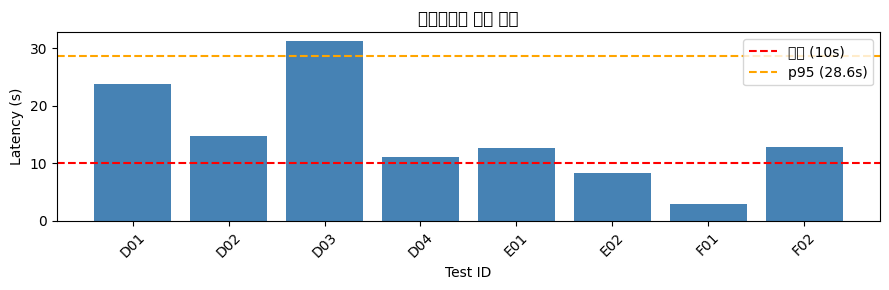

In [33]:
latency_vals = pipeline_df[pipeline_df['status'] == 'OK']['latency_s'].dropna()

if len(latency_vals) > 0:
    p50  = np.percentile(latency_vals, 50)
    p95  = np.percentile(latency_vals, 95)
    pmax = latency_vals.max()

    print("---응답 시간 분포 ---")
    print(f"  p50 : {p50:.2f}s")
    print(f"  p95 : {p95:.2f}s  ← 목표: 10초 이내")
    print(f"  max : {pmax:.2f}s")
    print()
    print("⭕ p95 기준 통과" if p95 <= 10 else "❌ p95 기준 초과 → 모델/top_k 조정 필요")

    # 시각화 
    plt.figure(figsize=(9, 3))
    plt.bar(pipeline_df['test_id'], pipeline_df['latency_s'], color='steelblue')
    plt.axhline(y=10,  color='red',    linestyle='--', label='목표 (10s)')
    plt.axhline(y=p95, color='orange', linestyle='--', label=f'p95 ({p95:.1f}s)')
    plt.xlabel('Test ID')
    plt.ylabel('Latency (s)')
    plt.title('파이프라인 응답 시간')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 9. Faithfulness 및 톤앤매너 검증

In [20]:
faith_df = pipeline_df[pipeline_df['Faithfulness'].notna()]
tone_df  = pipeline_df[pipeline_df['Tone_OK'].notna()]

print("=== Faithfulness (근거 기반 답변 여부) ===")
if len(faith_df) > 0:
    faith_rate = faith_df['Faithfulness'].mean()
    print(f"근거 있음 비율: {faith_rate:.1%}")
    print(f"(기준: 검색 문서와 단어 3개 이상 겹침)")
else:
    print("측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

print()
print("=== 톤앤매너 (확답 표현 없는지) ===")
if len(tone_df) > 0:
    tone_rate = tone_df['Tone_OK'].mean()
    print(f"확답 표현 없음 비율: {tone_rate:.1%}")
    print(f"(기준: langgraph_integration.ipynb DEFINITIVE_PATTERNS 미포함)")
else:
    print("측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

KeyError: 'Faithfulness'

### 10. 최종 결과 요약

In [21]:
print('-' * 100)
print("Phase 1 단위 테스트")
print('-' * 100)
for df, name in [
    (a_df, "Group A - moderator_1 (정규식)"),
    (b_df, "Group B - moderator_2 (LLM+JSON파싱)"),
    (c_df, "Group C - moderator_3 (정규식+LLM)"),
]:
    ok = (df['status'] == 'PASS').sum()
    total = len(df)
    print(f"{name}: {ok}/{total} ({ok/total*100:.0f}%)")

print()
print('-' * 100)
print("Phase 2 통합 테스트")
print('-' * 100)
for group in pipeline_df['group'].unique():
    g = pipeline_df[pipeline_df['group'] == group]
    ok = (g['status'] == 'OK').sum()
    total = len(g)
    print(f"{group}: {ok}/{total} ({ok/total*100:.0f}%)")

print()
print('-' * 100)
print('핵심 성능 지표')
print('-' * 100)

faith_rate = faith_df['Faithfulness'].mean() if len(faith_df) > 0 else None
tone_rate  = tone_df['Tone_OK'].mean() if len(tone_df) > 0  else None

summary = {
    'Recall@3 (평균)': f"{valid['Recall@3'].mean():.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'MRR (평균)': f"{valid['MRR'].mean():.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'Hit Rate': f"{hit_rate:.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'p95 Latency': f"{p95:.2f}s" if len(latency_vals) > 0 else "N/A (Qdrant 필요)",
    'Faithfulness': f"{faith_rate:.1%}" if faith_rate is not None else "N/A (Qdrant 필요)",
    '톤앤매너 준수율': f"{tone_rate:.1%}" if tone_rate is not None  else "N/A (Qdrant 필요)",
}

for 지표이름, 지표값 in summary.items():
    print(f"{지표이름:20s}: {지표값}")

----------------------------------------------------------------------------------------------------
Phase 1 단위 테스트
----------------------------------------------------------------------------------------------------
Group A - moderator_1 (정규식): 10/10 (100%)
Group B - moderator_2 (LLM+JSON파싱): 5/6 (83%)
Group C - moderator_3 (정규식+LLM): 5/5 (100%)

----------------------------------------------------------------------------------------------------
Phase 2 통합 테스트
----------------------------------------------------------------------------------------------------
정상통과: 0/4 (0%)
할루시네이션방지: 0/2 (0%)
유사도차단: 0/2 (0%)

----------------------------------------------------------------------------------------------------
핵심 성능 지표
----------------------------------------------------------------------------------------------------


NameError: name 'faith_df' is not defined